# Week 2: OCR Basics and Image Preprocessing
Objective

Extract text from:

* Invoice
* Receipt
* Handwritten Notes

using OCR and improve the OCR accuracy using image preprocessing.

# Section 1: Install Required Libraries

In [1]:
!pip install easyocr
!pip install opencv-python-headless
!pip install pytesseract
!apt-get install tesseract-ocr -y

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 18.3 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


# Section 2: Import Libraries

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pytesseract
import easyocr

from google.colab import files

#Section 3: Upload Images

In [3]:
uploaded = files.upload()

Saving handwritten.jpg to handwritten.jpg
Saving invoice.png to invoice.png
Saving receipt.jpg to receipt.jpg


# Section 4: Display Image

In [4]:
def show_image(img, title):

    plt.figure(figsize=(8,8))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

# Section 5: Load Images

In [5]:
invoice = cv2.imread("invoice.jpg")
receipt = cv2.imread("receipt.jpg")
handwritten = cv2.imread("handwritten.jpg")

Show Images

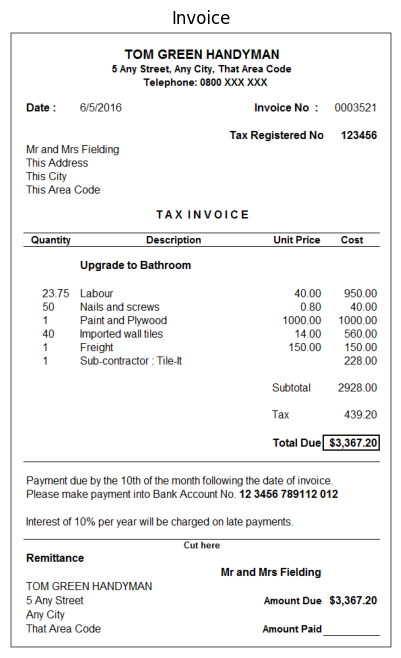

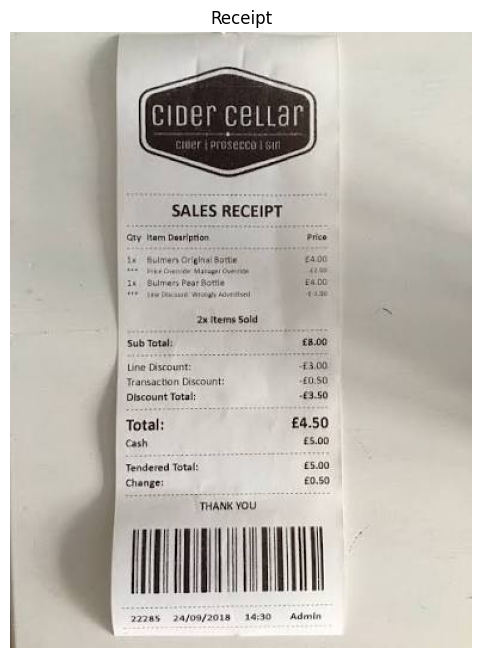

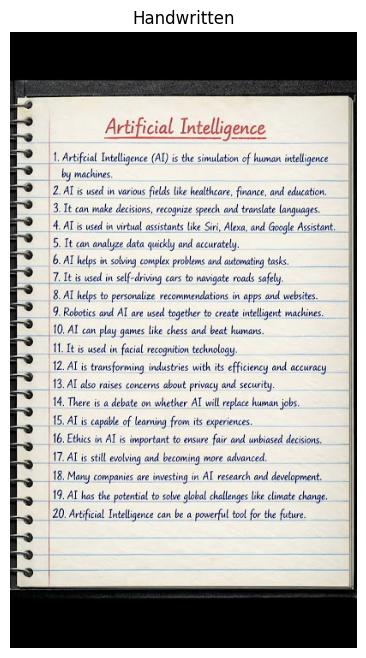

In [7]:
invoice = cv2.imread("invoice.png") # Correctly load the invoice image
show_image(invoice,"Invoice")
show_image(receipt,"Receipt")
show_image(handwritten,"Handwritten")

# Section 6: OCR Using EasyOCR (Original Images)

In [8]:
reader = easyocr.Reader(['en'])

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

OCR Function

In [9]:
def easyocr_result(image):

    result = reader.readtext(image)

    text=""

    for item in result:
        text += item[1]+"\n"

    return text

Invoice OCR

In [10]:
print(easyocr_result(invoice))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TOM GREEN HANDYMAN
Street; Any City, That Area Code
Telephone: 0800 XXX XXX
Date
6/5/2016
Invoice No
0003521
Tax Registered No
123456
Mr and Mrs Fielding
This Address
This City
This Area Code
TAX INVOICE
Quantity
Description
Unit Price
Cost
Upgrade to Bathroom
23.75
Labour
40.00
950.00
50
Nails and screws
40.00
Paint and Plywood
1000
1000.00
Imported wall tiles
14.00
560.00
Freight
150.00
150.00
Sub-contractor : Tile-It
228.00
Subtotal
2928.00
Tax
439.20
Total Due
53,367.20
Payment due by the 1Oth of the month following the date of invoice.
Please make payment into Bank Account No. 12 3456 789112 012
Interest of 10% per year will be charged on late payments
Cut here
Remittance
Mr and Mrs Fielding
TOM GREEN HANDYMAN
5 Any Street
Amount Due
S3,367.20
Any City
That Area Code
Amount Paid
Any



Receipt OCR

In [11]:
print(easyocr_result(receipt))

clder cellar
Cipar | prusuCCu IG1m
SALES RECEIPT
potrlntet
67t Or
Buim <, Feuriatle
Me
Lal Luctttal
AfmEE
Sold
Sab Tetal:
FEC
Unc Mco
FcAecIO
Liscount:
LUSU
Dlcount Iotu
Total:
E4.50
95.0D
Henicancd
Tetal:
amm
dianze
20,51
THANK YOU
4/u zo e
el
drmn



Handwritten OCR

In [12]:
print(easyocr_result(handwritten))

Artificial Intelligence
Artifcial
(AI) is the simulation of human intelligence
mackines_
2. AI
used
Vardus
fields like healthcare , finance,
educaticn,
3 It
make decisiors, recognize speech
translate languages:
AI is used
virtual assistants like Siri,
ana
Google Assistant,
It can analuze data
quickly and accurately:
AI helps in solving complex prcblems and automating tasks .
7.1t
used
self-driving cars
navigate roads safely:
8.AI helps to personalize
reccamendnticns
apps and websites
Robotics and
used togetker to create intelligent machines
10. AI
play games
like cness and beal numans
I1. It is used
facial recoguition
12. AI
transforming industries with its efficiency and accuracy
13. AL alsc
Fa4?
cncerh
aexut privacy &n4 security:
14. There
aebani
whether Al will replace human jobs.
15.AI is capalle of learning from its experiences.
16. Ethics in AI
imvortant to esure
and unbiased
17.AI
still evolving and becoming
more
advanced 
compamies
unvesting
A[ research ana
development:
19.AI h

# Section 7: Image Preprocessing

Step 1 Grayscale

In [13]:
def grayscale(img):

    return cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

Step 2 Thresholding

In [14]:
def threshold(img):

    return cv2.threshold(
        img,
        0,
        255,
        cv2.THRESH_BINARY+cv2.THRESH_OTSU
    )[1]

Step 3 Denoising

In [15]:
def denoise(img):

    return cv2.fastNlMeansDenoising(img)

Step 4 Contrast Enhancement

In [16]:
def contrast(img):

    return cv2.equalizeHist(img)

Step 5 Deskew

In [17]:
def deskew(image):

    gray=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)

    coords=np.column_stack(np.where(gray>0))

    angle=cv2.minAreaRect(coords)[-1]

    if angle<-45:
        angle=-(90+angle)
    else:
        angle=-angle

    h,w=image.shape[:2]

    center=(w//2,h//2)

    M=cv2.getRotationMatrix2D(center,angle,1)

    rotated=cv2.warpAffine(
        image,
        M,
        (w,h),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_REPLICATE
    )

    return rotated

#Section 8: Complete Preprocessing Pipeline

In [18]:
def preprocess(image):

    gray=grayscale(image)

    gray=contrast(gray)

    gray=denoise(gray)

    gray=threshold(gray)

    return gray

Section 9: Preprocess Images

In [19]:
invoice_pre = preprocess(invoice)
receipt_pre = preprocess(receipt)
handwritten_pre = preprocess(handwritten)

Display Results

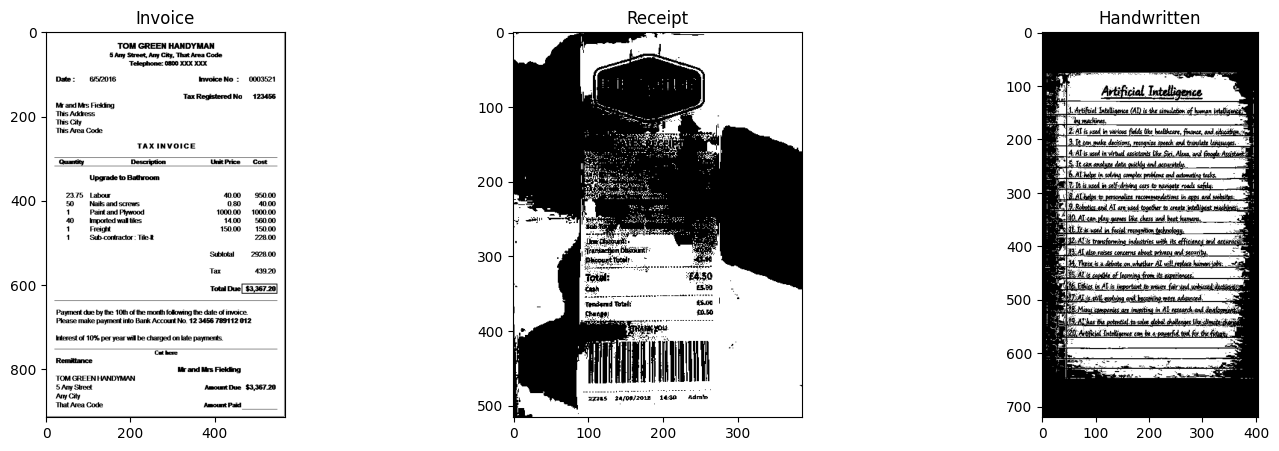

In [20]:
plt.figure(figsize=(18,5))

plt.subplot(131)
plt.imshow(invoice_pre,cmap="gray")
plt.title("Invoice")

plt.subplot(132)
plt.imshow(receipt_pre,cmap="gray")
plt.title("Receipt")

plt.subplot(133)
plt.imshow(handwritten_pre,cmap="gray")
plt.title("Handwritten")

plt.show()

#Section 10: OCR After Preprocessing

In [21]:
print(reader.readtext(invoice_pre,detail=0))

['TOM GREEN HANDYMAN', 'SteetAly Cry; That Mea Code', 'Teleptane  03n XXX XXX', 'Date', '64552016', 'Invoice No', '0003521', 'Tax Registered No', '123456', 'M ard Mrs Fiekting', 'This Adtess', 'This City', 'This Area Code', 'TAX INVOICE', 'Deraaikn', 'UltPuice', 'Cost', 'Upgrade@ Batuoom', '23.75', 'Labou', '40.00', '95000', '50', 'Nail amd scews', '0.80', '40.00', 'Paint ard Ptywood', '1000.00', '1000.00', '40', 'tmpoted wal tikes', '1400', '560.00', 'Freigtt', '15000', '150.00', 'Sub cohrador _', 'Tikt', '22800', 'Subtotal', '292800', 'Tax', '439.20', 'TotDuel', '9367 2', 'Payent due by tte ICth cftte mnth folowingtte date dfimoice', 'Ptease make paynett irto Bark AccoutNo 12 3456 789112 012', 'hterest of 107 per year w be charged on ate payerts_', 'Uteee', 'Remeiance', 'aWbs', 'Fiekeng', 'TOM GREENHANDYMAN', '5 Ally Street', 'AnouDue {3,36720', 'Ay City', 'ThatArea Code', 'AnoutPayd', 'NT}', 'Du']


In [22]:
print(reader.readtext(receipt_pre,detail=0))

['E560', 'Teacamg', 'elt', 'Hunn', 'Sur', '{LEo', 'ITt', '1404Z0b', '14+90', 'Eumi']


In [23]:
print(reader.readtext(handwritten_pre,detail=0))

['Atificicl Itellgence', 'AtitidL Lbllieete Glis tusinubiaef=', 'buliget', '4is', 'LAisusd', 'vies', 'futlkulat fnatwueaet', '4 Iuautut driinns Ietcgnizeeuk eu tanbte lireds', '#Ainuuhitu asitt lk Sidbainxktat', 'eantuattwiceublc', 'bacrxkputbuauatntintk', 'il4d', 'naleticn ttaatend sily', 'Mitli reulnlttinu needdweit', 'etnuddLatudd', 'uebittillittalte', 'ALbaeebay as Lia cess', 'bythuag', '[iwdi fridnagii_', 'duibebmit inubc_wi ib cfiimted uia', 'Adreaehu cqans cbuut prledLediequitl', 'Etanuiiur', 'Lcnic', '@44', 'eiifei', 'niiek', 'Eiaw ALirotiteran', 'uiaL', 'Linttiarin et', 'iriy', 'Etatilen', 'Jnltiez', 'Eud_', 'b', 'ALbde', 'ttk', '1ui', 'uikil']


In [24]:
print(pytesseract.image_to_string(receipt_pre))

‘eon |
00

you

wnt

‘aajesizon 1430 Adee

 



#Section 11: OCR Using Tesseract

In [25]:
print(pytesseract.image_to_string(handwritten_pre))

Section 12: Compare OCR

In [26]:
print("======== INVOICE ========")

print("\nOriginal OCR")
print(easyocr_result(invoice))

print("\nPreprocessed OCR")
print(reader.readtext(invoice_pre,detail=0))

======== INVOICE ========

Original OCR


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TOM GREEN HANDYMAN
Street; Any City, That Area Code
Telephone: 0800 XXX XXX
Date
6/5/2016
Invoice No
0003521
Tax Registered No
123456
Mr and Mrs Fielding
This Address
This City
This Area Code
TAX INVOICE
Quantity
Description
Unit Price
Cost
Upgrade to Bathroom
23.75
Labour
40.00
950.00
50
Nails and screws
40.00
Paint and Plywood
1000
1000.00
Imported wall tiles
14.00
560.00
Freight
150.00
150.00
Sub-contractor : Tile-It
228.00
Subtotal
2928.00
Tax
439.20
Total Due
53,367.20
Payment due by the 1Oth of the month following the date of invoice.
Please make payment into Bank Account No. 12 3456 789112 012
Interest of 10% per year will be charged on late payments
Cut here
Remittance
Mr and Mrs Fielding
TOM GREEN HANDYMAN
5 Any Street
Amount Due
S3,367.20
Any City
That Area Code
Amount Paid
Any


Preprocessed OCR
['TOM GREEN HANDYMAN', 'SteetAly Cry; That Mea Code', 'Teleptane  03n XXX XXX', 'Date', '64552016', 'Invoice No', '0003521', 'Tax Registered No', '123456', 'M ard Mrs Fiekting', 'Thi